# Strain across the Brunt Ice Shelf (advanced)

In this example, we will explore how strain rates have changed across the Brunt Ice Shelf from 2016 through 2025. Strain rates can be a useful indicator of where rifts are growing, so can help us to understand how Antarctica's ice shelves are changing and may provide useful laboratories for studying rift propagation through ice in general. 

This analysis will require us to utilise ice speeds over a moderately large area and time period, so we will use the _cubed_ Antarctica velocity zarr store, which has the optimium chunk definition for this. We will use **Dask** to parallelize our computations and **Xarray** to handle lazy loading. 

Finally, we will calculate the strain rates using Tom Chudley's excellent `strain_tools` Python package (Chudley et al. 2026), which is documented in detail [here](https://glacier-strain-tools.readthedocs.io/).

## 1. Environment setup and Dask configuration

When working with cloud-native data formats like Zarr over AWS S3, I/O operations and network latency are often the biggest bottlenecks. 

In this first cell, we spin up a local Dask cluster to distribute our processing across multiple CPU cores. We also explicitly configure the S3 HTTP backend to allow more connections and retries. This ensures that when Dask requests hundreds of data chunks simultaneously, the connection doesn't time out or drop.

In [1]:
import warnings
import xarray as xr
import numpy as np
import pandas as pd
import dask
from dask.distributed import LocalCluster, Client
import zarr
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from pyproj import Transformer
import strain_tools as st

# Spin up a local Dask cluster, limiting the number of workers and the number of threads per work
cluster = LocalCluster(n_workers=4, threads_per_worker=2)
client = Client(cluster)

# 1. Cap Zarr's internal HTTP concurrency per worker
zarr.config.set({"async.concurrency": 2})

# Configure the HTTP backend to allow more time for large chunks
s3_options = {
    "anon": True, 
    "config_kwargs": {
        "max_pool_connections": 50,  
        "retries": {
            "max_attempts": 10,      
            "mode": "standard"       
        }
    }
}

# Display the dashboard link so users can watch the processing graph
print(f"Dask Dashboard: {client.dashboard_link}")

C:\Users\gg1bjd\AppData\Local\anaconda3\envs\shiver_env\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52390 instead
  warnings.warn(


Dask Dashboard: http://127.0.0.1:52390/status


## 2. Lazy loading and spatial cropping

Here we connect to the Zarr store using Xarray, load the metadata and crop the Zarr lazily to our area of interest, in exactly the same way we did in earlier examples. We use two areas of interest here - one covering the entire ice shelf, and another centred around the late Chasm-1. 

In [2]:
# Load and crop data
zarr_path = "s3://us-west-2.opendata.source.coop/uos-shiver/antarctica/antarctica_multisource_velocity_cubed.zarr"

ds = xr.open_dataset(zarr_path, engine="zarr", storage_options=s3_options)

# Crop to the Brunt Ice Shelf
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
tl_x, tl_y = transformer.transform(-25.412, -73.356)
br_x, br_y = transformer.transform(-24.061, -76.620)
min_x, max_x = min(tl_x, br_x), max(tl_x, br_x)
min_y, max_y = min(tl_y, br_y), max(tl_y, br_y)
ds = ds.sel(
    x=slice(min_x, max_x), 
    y=slice(max_y, min_y)
)

# Also define a zoomed in area around Chasm-1
tl_x_zoom, tl_y_zoom = transformer.transform(-27.0215, -75.2954)
br_x_zoom, br_y_zoom = transformer.transform(-26.0599, -76.1205)
min_x_zoom, max_x_zoom = min(tl_x_zoom, br_x_zoom), max(tl_x_zoom, br_x_zoom)
min_y_zoom, max_y_zoom = min(tl_y_zoom, br_y_zoom), max(tl_y_zoom, br_y_zoom)

# Crop to target time period
years = np.arange(2016, 2026)

# Set resolution and lengh scale
resolution = abs(float(ds.x[1] - ds.x[0]))
length_scale = 1000

print(f"Cropped dataset size: {ds.sizes}")

Cropped dataset size: Frozen({'time': 2790, 'y': 1557, 'x': 930, 'bnds': 2})


## 3. Defining a custom function for winter means

Ice velocity data derived from optical and SAR satellites can be noisy, and availability often fluctuates with the seasons. To create a stable, comparable velocity field for our strain calculations, we want to average the data over the austral winter (here we'll use May to September) for each year.

Below, we define a pure NumPy function to calculate these temporal means. We intentionally design this function to process the time axis last, and we use `warnings.catch_warnings` to silently handle grid cells that contain only NaNs.

In [3]:
def calc_winter_means_numpy(data, time_vals, start_year, end_year):
    """
    Computes the temporal mean across May-September for each year.
    Designed for xr.apply_ufunc: 'time' is always the last axis of `data`.
    """
    times = pd.DatetimeIndex(time_vals)
    n_years = end_year - start_year + 1
    
    # Pre-allocate output array -> shape: (..., n_years)
    out_shape = data.shape[:-1] + (n_years,)
    output = np.zeros(out_shape, dtype=np.float32)
    
    # Suppress RuntimeWarnings for slices that are entirely NaN (open ocean/no data)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        for i, year in enumerate(range(start_year, end_year + 1)):
            # Winter mask: specified year, months May (5) to Sept (9)
            mask = (times.year == year) & (times.month >= 5) & (times.month <= 9)
            
            if mask.any():
                output[..., i] = np.nanmean(data[..., mask], axis=-1)
            else:
                output[..., i] = np.nan
            
    return output

## 4. Applying the function with Dask

To apply our custom NumPy function across our massive Xarray dataset, we use `xr.apply_ufunc`. This is a powerful Xarray feature that maps standard NumPy functions across chunked Dask arrays. 

By setting `dask='parallelized'`, we tell Dask to distribute this winter-mean calculation across all the workers we spun up in Step 1. After calculating the means for both our $vx$ and $vy$ velocities, we assign the `year` coordinate back to the outputs and slice out our Chasm-1 zoomed area. 

*Note: Because Xarray is lazy, no computation actually happens here yet. We are simply building the Dask task graph.*

In [4]:
# Apply the custom ufunc to vx
mean_vx = xr.apply_ufunc(
    calc_winter_means_numpy,
    ds['vx'],
    ds['time'],
    kwargs={'start_year': years[0], 'end_year': years[-1]},
    input_core_dims=[['time'], ['time']],
    output_core_dims=[['year']],
    vectorize=False,               
    dask='parallelized',           
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={'output_sizes': {'year': len(years)}}
)

# Apply the custom ufunc to vy
mean_vy = xr.apply_ufunc(
    calc_winter_means_numpy,
    ds['vy'],
    ds['time'],
    kwargs={'start_year': years[0], 'end_year': years[-1]},
    input_core_dims=[['time'], ['time']],
    output_core_dims=[['year']],
    vectorize=False,
    dask='parallelized',
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={'output_sizes': {'year': len(years)}}
)

# Assign the 'year' coordinate back to the reduced outputs
mean_vx = mean_vx.assign_coords(year=years)
mean_vy = mean_vy.assign_coords(year=years)

# And get the zoomed in areas
mean_vx_zoom = mean_vx.sel(x=slice(min_x_zoom, max_x_zoom), y=slice(max_y_zoom, min_y_zoom))
mean_vy_zoom = mean_vy.sel(x=slice(min_x_zoom, max_x_zoom), y=slice(max_y_zoom, min_y_zoom))

## 5. Calculating and plotting strain rates

Now we bring it all together. For each year, we call `.compute()` to trigger Dask to execute the graph, download the cropped winter means into local memory, and pass them to `strain_tools`. 

We are specifically calculating the **first principal strain rate** ($e_1$). Positive values of $e_1$ (shown in red) represent extending strain, which highlights areas where the ice shelf is pulling apart. We also apply a `length_scale` (in meters) to smooth the velocity gradients, which helps prevent small-scale noise from creating artificial spikes in our strain calculations.

Processing and plotting winter 2016...
Processing and plotting winter 2017...
Processing and plotting winter 2018...
Processing and plotting winter 2019...
Processing and plotting winter 2020...
Processing and plotting winter 2021...
Processing and plotting winter 2022...
Processing and plotting winter 2023...
Processing and plotting winter 2024...
Processing and plotting winter 2025...


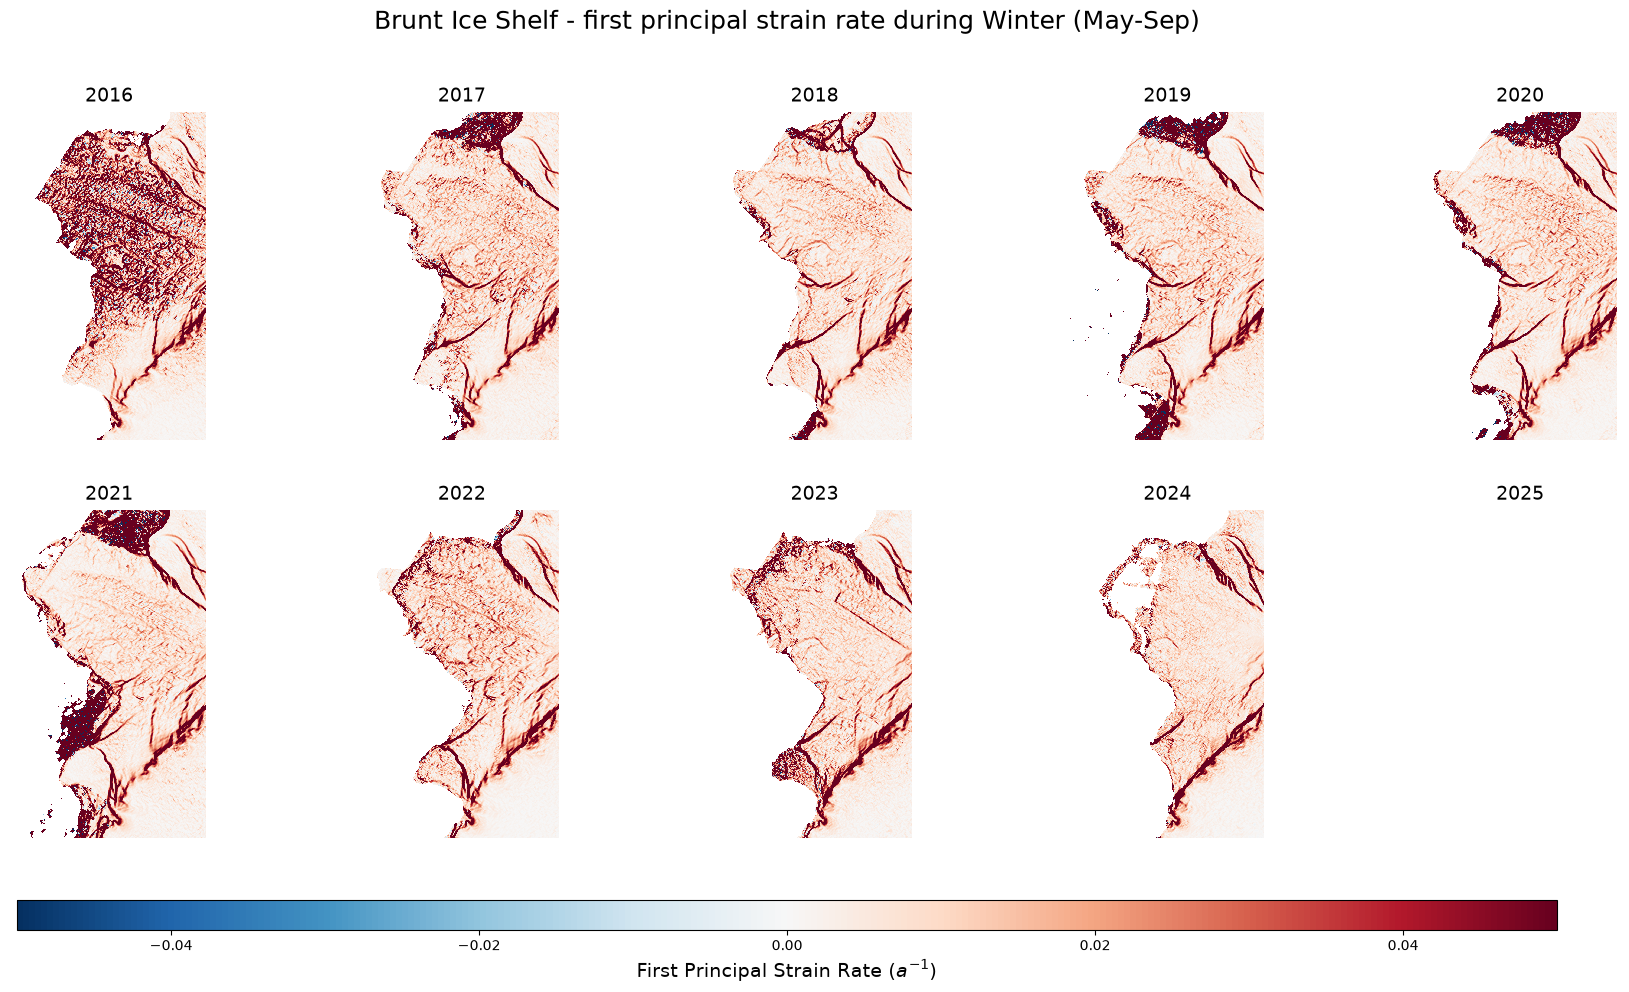

In [5]:
# calculate and plot strain rates

# Create a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Set visual bounds for strain rates 
strain_vmin, strain_vmax = -0.05, 0.05 

for i, year in enumerate(years):
    ax = axes[i]
    print(f"Processing and plotting winter {year}...")
    
    # Pul the 2D velocity components into memory
    vx_yr = mean_vx.sel(year=year).compute().values
    vy_yr = mean_vy.sel(year=year).compute().values
    
    # Calculate logarithmic strain
    e_xx, e_yy, e_xy = st.strain.logarithmic(vx_yr, vy_yr, 
                                   pixel_size=resolution, 
                                   length_scale=length_scale, 
                                   unit_time='a')
    
    # Calculate principal strain
    principal = st.strain.principal(e_xx, e_yy, e_xy)
    
    # Extract the first principal strain rate (e1)
    try:
        e1 = principal.e1
    except AttributeError:
        e1 = principal[0]
        
    # Re-wrap in xarray and plot
    da_e1 = xr.DataArray(e1, coords=[ds.y, ds.x], dims=['y', 'x'])
    im = da_e1.plot.imshow(ax=ax, cmap='RdBu_r', vmin=strain_vmin, vmax=strain_vmax, add_colorbar=False)
    
    # Format this axis
    ax.set_title(f"{year}", fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')

# Make it pretty
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('First Principal Strain Rate ($a^{-1}$)', fontsize=14)

plt.suptitle('Brunt Ice Shelf - first principal strain rate during Winter (May-Sep)', fontsize=18, y=0.98)
plt.show()

## 6. Zooming in on Chasm-1 and iceberg calving

The native data resolution, error and quality vary year-to-year, but these plots show quite nicely how the strain rates around 'Chasm-1' evolved year to year, eventually resulting in the calving of a very large iceberg (A-81) on 22 January 2023. 

You can read more about the creation of A-81 [here](https://www.bas.ac.uk/news/brunt-ice-shelf-in-antarctica-calves-giant-iceberg/) and [here](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Giant_iceberg_breaks_away_from_Antarctic_ice_shelf).

Below is a more detailed plot, focused specifically on the evolution of Chasm-1.

Processing and plotting winter 2016 (Zoomed)...
Processing and plotting winter 2017 (Zoomed)...
Processing and plotting winter 2018 (Zoomed)...
Processing and plotting winter 2019 (Zoomed)...
Processing and plotting winter 2020 (Zoomed)...
Processing and plotting winter 2021 (Zoomed)...
Processing and plotting winter 2022 (Zoomed)...
Processing and plotting winter 2023 (Zoomed)...
Processing and plotting winter 2024 (Zoomed)...
Processing and plotting winter 2025 (Zoomed)...


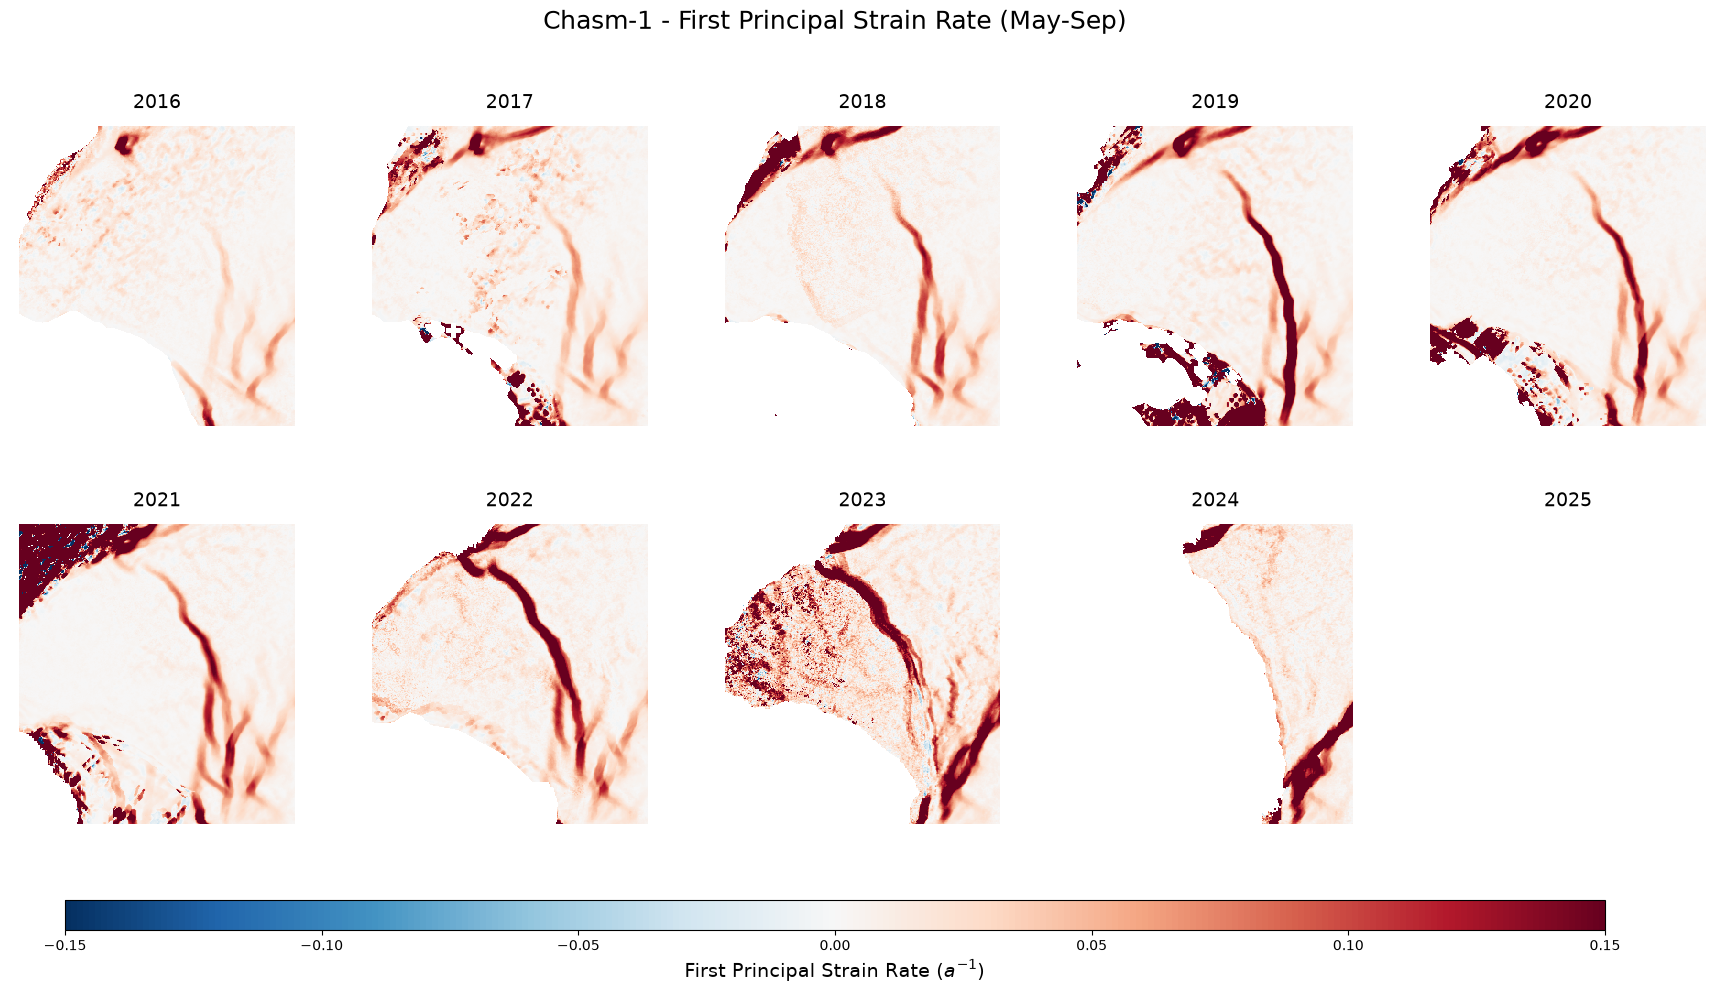

In [13]:
# Show zoomed area
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Set visual bounds for strain rates 
strain_vmin, strain_vmax = -0.15, 0.15 

for i, year in enumerate(years):
    ax = axes[i]
    print(f"Processing and plotting winter {year} (Zoomed)...")
    
    # .compute() pulls only the small, zoomed 2D spatial array into local memory
    vx_yr = mean_vx_zoom.sel(year=year).compute().values
    vy_yr = mean_vy_zoom.sel(year=year).compute().values
    
    # Calculate logarithmic strain
    e_xx, e_yy, e_xy = st.strain.logarithmic(vx_yr, vy_yr, 
                                             pixel_size=resolution, 
                                             length_scale=length_scale, 
                                             unit_time='a')
    
    # Calculate principal strain
    principal = st.strain.principal(e_xx, e_yy, e_xy)
    
    # Extract the first principal strain rate (e1)
    try:
        e1 = principal.e1
    except AttributeError:
        e1 = principal[0]
        
    # Wrap in xarray and plot
    da_e1 = xr.DataArray(e1, coords=[mean_vx_zoom.y, mean_vx_zoom.x], dims=['y', 'x'])
    im = da_e1.plot.imshow(ax=ax, cmap='RdBu_r', vmin=strain_vmin, vmax=strain_vmax, add_colorbar=False)
    
    # Format this axis
    ax.set_title(f"{year}", fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')

# Make it pretty
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('First Principal Strain Rate ($a^{-1}$)', fontsize=14)
plt.suptitle('Chasm-1 - First Principal Strain Rate (May-Sep)', fontsize=18, y=0.98)
plt.show()

In [7]:
# Clean up local cluster
client.close()
cluster.close()